# EDA

## Import lib

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Import dataset

In [2]:
df = pd.read_pickle('../data/cleaned-data/cleaned.pkl')

In [3]:
df.sample()

,order-id,order-date,ship-date,ship-mode,customer-id,customer-name,segment,country,city,state,postal-code,region,product-id,category,sub-category,product-name,sales,quantity,discount,profit
8385,CA-2017-137582,2017-09-04,2017-09-08,Standard Class,CV-12805,Cynthia Voltz,Corporate,United States,Oakland,California,94601,West,OFF-BI-10001757,Office Supplies,Binders,Pressboard Hanging Data Binders for Unburst Sh...,11.808,3,0.2,4.1328


In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 9993 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order-id       9993 non-null   str           
 1   order-date     9993 non-null   datetime64[us]
 2   ship-date      9993 non-null   datetime64[us]
 3   ship-mode      9993 non-null   category      
 4   customer-id    9993 non-null   str           
 5   customer-name  9993 non-null   str           
 6   segment        9993 non-null   category      
 7   country        9993 non-null   str           
 8   city           9993 non-null   str           
 9   state          9993 non-null   category      
 10  postal-code    9993 non-null   str           
 11  region         9993 non-null   category      
 12  product-id     9993 non-null   str           
 13  category       9993 non-null   category      
 14  sub-category   9993 non-null   category      
 15  product-name   9993 non-null   str   

## Categorise columns
**Numerical**:
- sales  
- quantity
- discount  
- profit  

**Categorical**
- ship-mode
- segment
- state
- region
- category
- sub-category

## Univariate Analysis

### On Numerical columns

#### `sales`

In [5]:
df['sales'].describe()

count     9993.000000
mean       229.852846
std        623.276074
min          0.444000
25%         17.280000
50%         54.480000
75%        209.940000
max      22638.480000
Name: sales, dtype: float64

<Axes: xlabel='sales', ylabel='Count'>

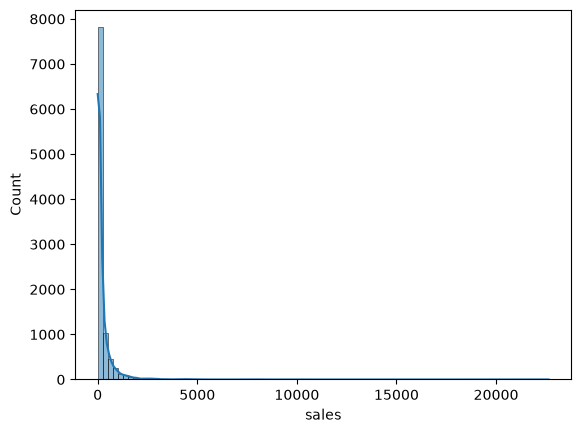

In [6]:
# To know the distribution of sales data
sns.histplot(data=df, x='sales', bins=90, kde=True)

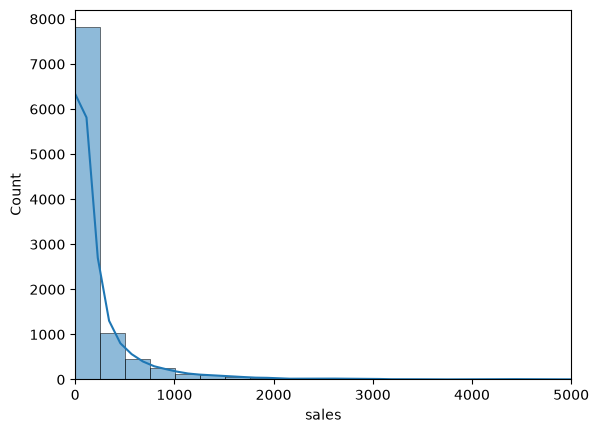

In [7]:
sns.histplot(data=df, x='sales', bins=90, kde=True)
plt.xlim(0,5000)
plt.show()

<Axes: xlabel='sales', ylabel='Density'>

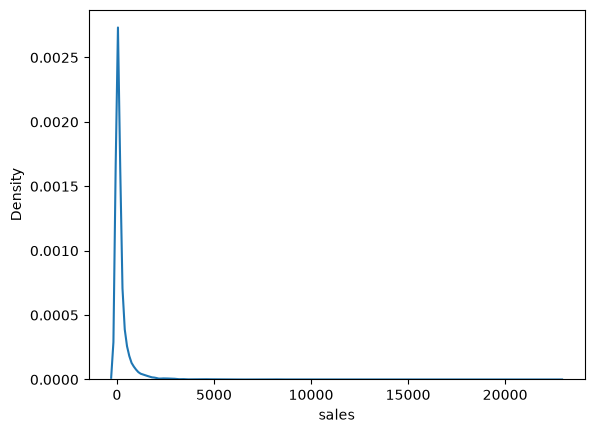

In [8]:
sns.kdeplot(data=df, x='sales')

<Axes: xlabel='sales'>

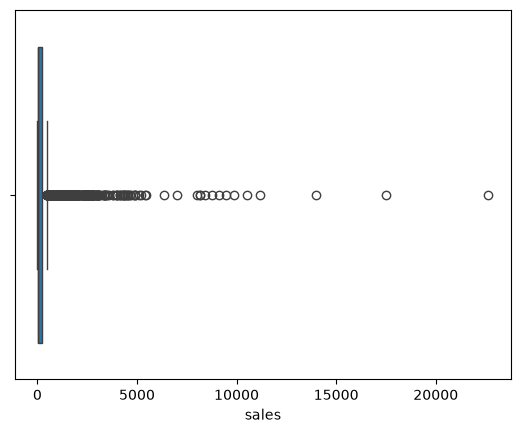

In [9]:
sns.boxplot(data=df, x='sales')

*By using above results of describe(), hist, kde and box plots.*  
- General observation  
*The sales data is highly right skewed and the 75% of the data is below 209.94*  
*The tail is very long from the median where median is 54.48 the largest value is 22638*  
*The box plot shows that there are large amount of outliers which shows that large amount of data is is of small values*  
- Business observation  
*Majory sales are below 209.94\$ around 75% sales specifically and there only 25% of sales are have crossed 209.94\\$ mark*
-----------

#### `quantity`

In [10]:
df.quantity.describe()

count    9993.000000
mean        3.789753
std         2.225149
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        14.000000
Name: quantity, dtype: float64

<Axes: xlabel='quantity', ylabel='Count'>

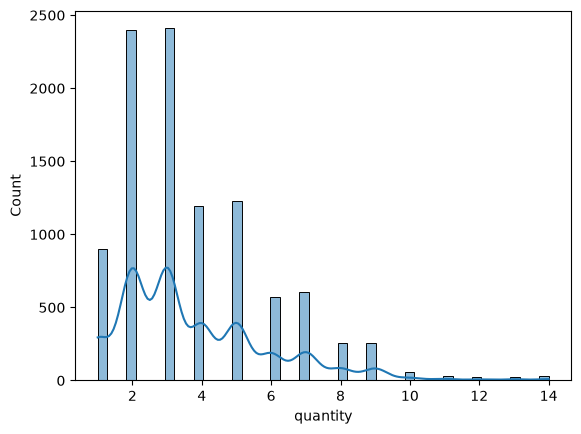

In [11]:
sns.histplot(data=df, x='quantity', kde=True)

<Axes: xlabel='quantity'>

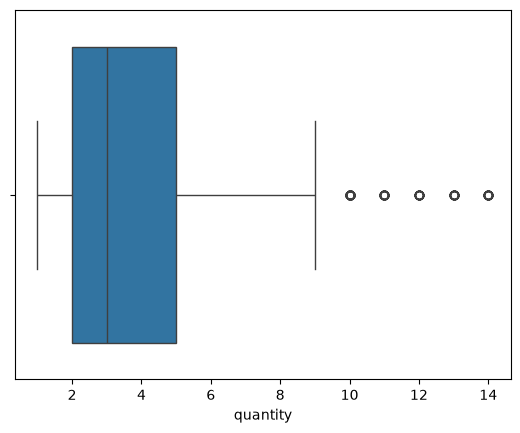

In [12]:
sns.boxplot(data=df, x='quantity')

**Observations:**  
- *The 75\% of the orders are ordering the at most 5 quantity of the product.* (The orders have different records for each product so 75\% of customes order product with at most 5 quantity)
- *The quantity data is also right skewed where the majority of the orders have quantity of 1 to 5, where max quantity is of 14*

#### `discount`

In [13]:
df.discount.describe()

count    9993.000000
mean        0.156188
std         0.206457
min         0.000000
25%         0.000000
50%         0.200000
75%         0.200000
max         0.800000
Name: discount, dtype: float64

<Axes: xlabel='discount', ylabel='Count'>

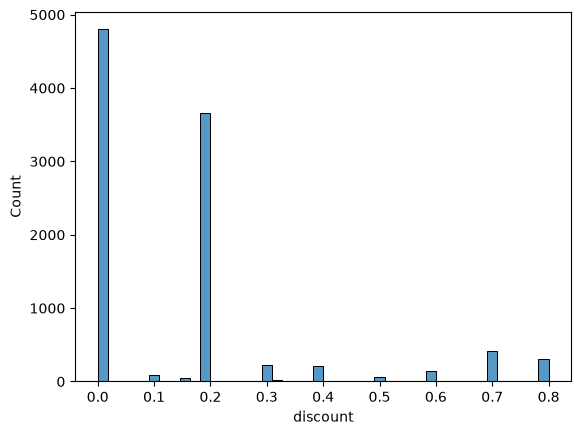

In [14]:
sns.histplot(data=df, x='discount')

<Axes: xlabel='discount'>

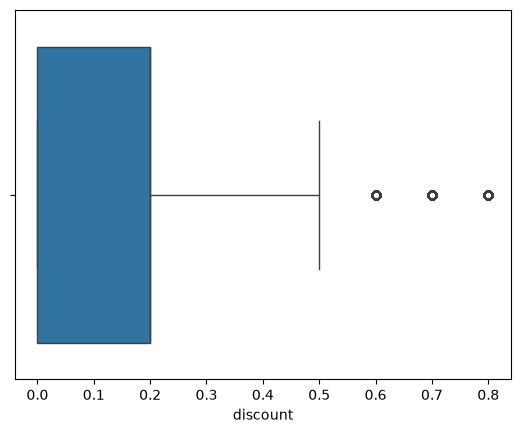

In [15]:
sns.boxplot(data=df, x='discount')

**Observations**  
- *The discount is largely given 0 or 20%*
- *25% sales are without any discount*  
- *There are very few discount given more than 20% but some given 70% & 80% also.*

#### `profit`

In [16]:
df['profit'].describe()

count    9993.000000
mean       28.660971
std       234.271476
min     -6599.978000
25%         1.731000
50%         8.671000
75%        29.364000
max      8399.976000
Name: profit, dtype: float64

<Axes: xlabel='profit', ylabel='Count'>

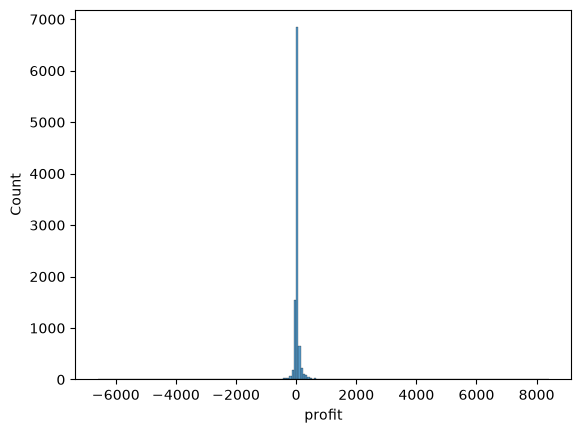

In [17]:
sns.histplot(data=df, x='profit')

(-500.0, 500.0)

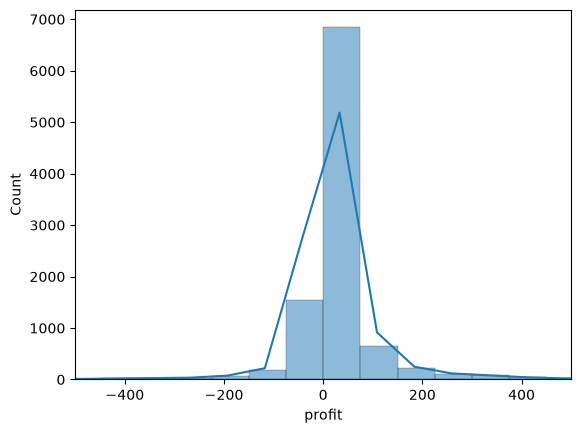

In [18]:
sns.histplot(data=df, x='profit', kde=True)
plt.xlim(-500, 500)

<Axes: xlabel='profit'>

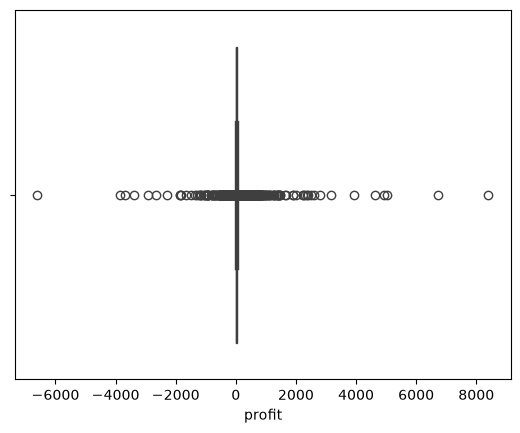

In [19]:
sns.boxplot(data=df, x='profit')

In [20]:
print("Number of orders made loss",df[df['profit']<0]['profit'].count())
print("Number of orders made profit",df[df['profit']>0]['profit'].count()) 
print("Number of orders did not made profit nor loss",df[df['profit']==0]['profit'].count()) 

Number of orders made loss 1870
Number of orders made profit 8058
Number of orders did not made profit nor loss 65


In [21]:
loss, profit, none = 1870, 8085, 65
total = loss + profit + none
percentofloss = (loss/total)*100
percentofprofit = (profit/total)*100
percentofnone = (none/total)*100
percentofloss, percentofprofit, percentofnone

(18.6626746506986, 80.688622754491, 0.6487025948103792)

**Observation:**  
- *The profit seems sharp peake at 0+*
- *The right tail is very long 8399 than left tail 6599*
- *There are more numbers of order which made profit than orders which made loss*
- *There are some orders which did not made profit bur also did not made loss (around 65 orders)*
- *Exact figures are Loss-18%, Profit-80% & 0.64% are nither profit nor loss*

### On categorical columns

#### `ship-mode`

In [22]:
df['ship-mode'].unique()

['Second Class', 'Standard Class', 'First Class', 'Same Day']
Categories (4, str): ['First Class', 'Same Day', 'Second Class', 'Standard Class']

In [25]:
df['ship-mode'].value_counts()

ship-mode
Standard Class    5967
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

In [32]:
labels =['Standard Class','Second Class','First Class','Same Day']

<Axes: xlabel='ship-mode', ylabel='count'>

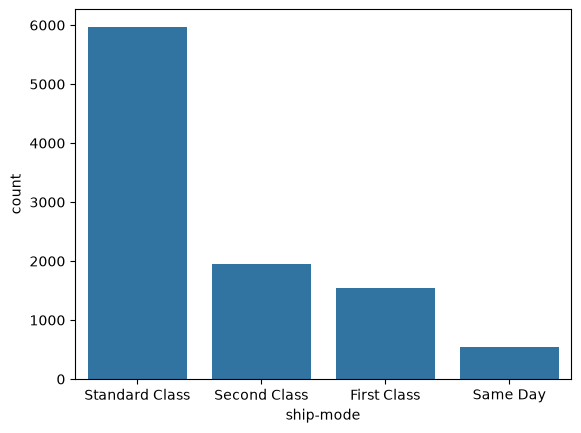

In [33]:
sns.countplot(data=df, x='ship-mode', order=labels)

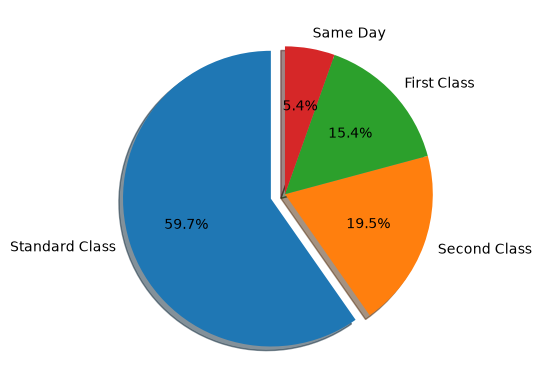

In [54]:
plt.pie(df['ship-mode'].value_counts(), labels=labels, autopct='%1.1f%%', explode=(0.1, 0, 0, 0), shadow=True, startangle=90)

**Observation:**  
- *There are mainly 4 options in the ship-mode Standard, Second, First and Same Day Class.*
- *The majority of the orders are in Standard Class bery few customer order the product on Same Day.*
- *The price of the Same Day Class is high so the users are less and Standard my have no price or minimal; price so it has majority of customer*
- *more than 50% of orders are Standard Class orders*
- *Standard Class-59.7%, Second class-19.5%, First Class-15.4% and Same Day-5.4%*
- *My personal suggection will be to decrease price of Second Class ship-mode it will definetly attract more customer to select Second Class* (The customers have 3 options second first or same day, the rich guy may choose same day, but the guy who is gonna order it in Standard Class can see the Second class price and the amount of customes choosing first and second are nearly same only 4% gap so by decreasing the Second class price it maybe possible that the some part of Standard will go to choose Second Class it may reduce first class customer little bit but the second class customer will increase)
----------

#### `segment`

In [57]:
df['segment'].unique()

['Consumer', 'Corporate', 'Home Office']
Categories (3, str): ['Consumer', 'Corporate', 'Home Office']

In [59]:
df['segment'].value_counts()

segment
Consumer       5191
Corporate      3020
Home Office    1782
Name: count, dtype: int64

<Axes: xlabel='segment', ylabel='count'>

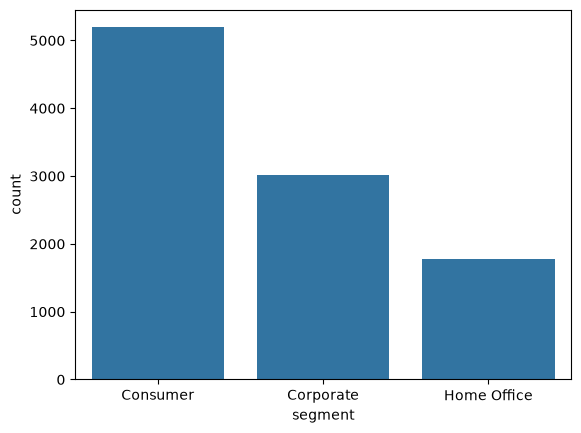

In [61]:
sns.countplot(data=df, x='segment')

In [63]:
labels = ['Consumer', 'Corporate segment', 'Home Office']

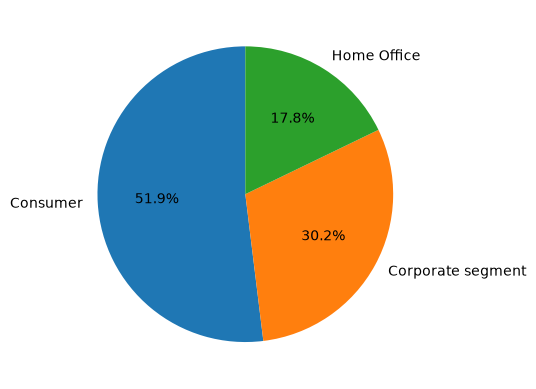

In [68]:
plt.pie(df['segment'].value_counts(), labels=labels, autopct='%1.1f%%', startangle=90)

**Observations:**  
- *There are three segments `Consumer`, `Corporate segment` and `Home Office`*
- *Almost half orders are by Consumers and other half are 30% from Corporate and 17 from Home Office*

#### `state`

In [69]:
df['state'].unique()

['Kentucky', 'California', 'Florida', 'North Carolina', 'Washington', ..., 'South Dakota', 'Idaho', 'North Dakota', 'Wyoming', 'West Virginia']
Length: 49
Categories (49, str): ['Alabama', 'Arizona', 'Arkansas', 'California', ..., 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']

In [74]:
df['state'].value_counts()

state
California              2001
New York                1128
Texas                    985
Pennsylvania             587
Washington               506
Illinois                 492
Ohio                     468
Florida                  383
Michigan                 255
North Carolina           249
Arizona                  224
Virginia                 224
Georgia                  184
Tennessee                183
Colorado                 182
Indiana                  149
Kentucky                 139
Massachusetts            135
New Jersey               130
Oregon                   124
Wisconsin                110
Maryland                 105
Delaware                  96
Minnesota                 89
Connecticut               82
Missouri                  66
Oklahoma                  66
Alabama                   61
Arkansas                  60
Rhode Island              56
Mississippi               53
Utah                      53
Louisiana                 42
South Carolina            42
Nevada  

In [75]:
labels = df['state'].value_counts().index

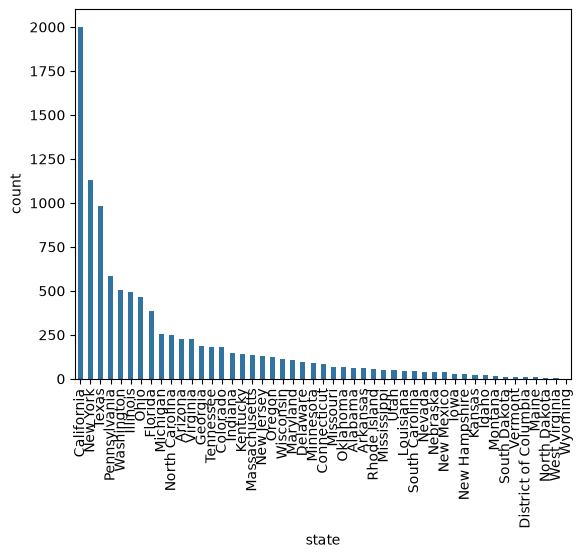

In [104]:
sns.countplot(data=df, x='state', order=labels, width=0.5)
plt.xticks(rotation=90, ha='center') 
plt.show()

**Observations:**
- *There are 49 states in total*
- *Big States have big amount of orders*

#### `region`

In [105]:
df['region'].unique()

['South', 'West', 'Central', 'East']
Categories (4, str): ['Central', 'East', 'South', 'West']

In [106]:
df['region'].value_counts()

region
West       3203
East       2847
Central    2323
South      1620
Name: count, dtype: int64

<Axes: xlabel='region', ylabel='count'>

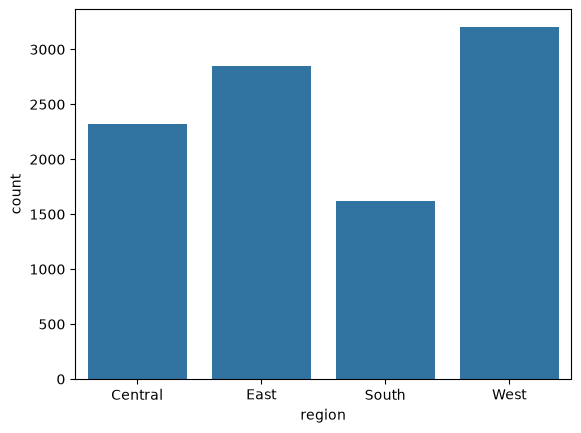

In [107]:
sns.countplot(data=df, x='region')

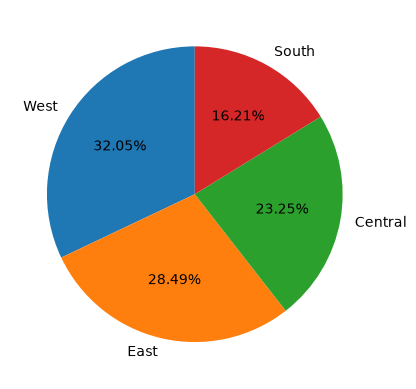

In [131]:
labels = df['region'].value_counts().index
plt.pie(df['region'].value_counts(), labels=labels, autopct='%1.2f%%', startangle=90)

**Observations:**  
- *The West region is having highest orders because one big city California*
- *The East side also have major cities like NY*
- *The central part of US have many city along with large one that is Texas*
- *the south part only have Florida as major city so the sales in south part is lowest*

#### `category`

In [132]:
df.category.unique()

['Furniture', 'Office Supplies', 'Technology']
Categories (3, str): ['Furniture', 'Office Supplies', 'Technology']

In [133]:
df['category'].value_counts()

category
Office Supplies    6026
Furniture          2120
Technology         1847
Name: count, dtype: int64

In [137]:
labels = df['category'].value_counts().index.to_list()

<Axes: xlabel='category', ylabel='count'>

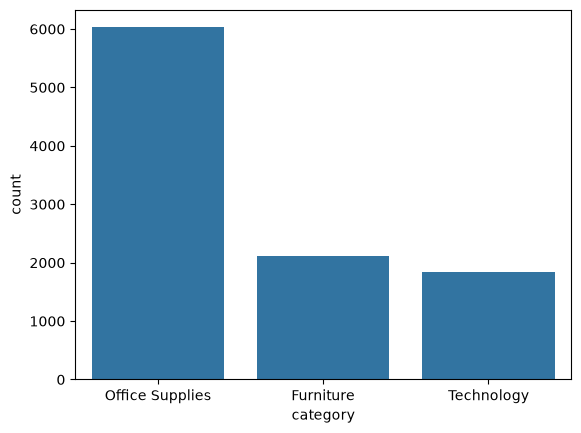

In [138]:
sns.countplot(data=df, x='category', order = labels)

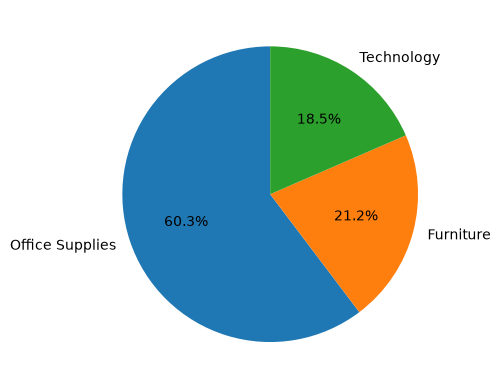

In [142]:
plt.pie(df['category'].value_counts(),labels=labels, autopct='%1.1f%%', startangle=90)

**Observations:**
- *The majority of orders are of category Office Supplies*
- *Office supplies-60%, Furniture-21% and Technology-18%*

#### `sub-category`

In [148]:
df['sub-category'].unique()

['Bookcases', 'Chairs', 'Labels', 'Tables', 'Storage', ..., 'Envelopes', 'Fasteners', 'Supplies', 'Machines', 'Copiers']
Length: 17
Categories (17, str): ['Accessories', 'Appliances', 'Art', 'Binders', ..., 'Phones', 'Storage', 'Supplies', 'Tables']

In [149]:
df['sub-category'].value_counts()

sub-category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          616
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

In [152]:
labels = df['sub-category'].value_counts().index

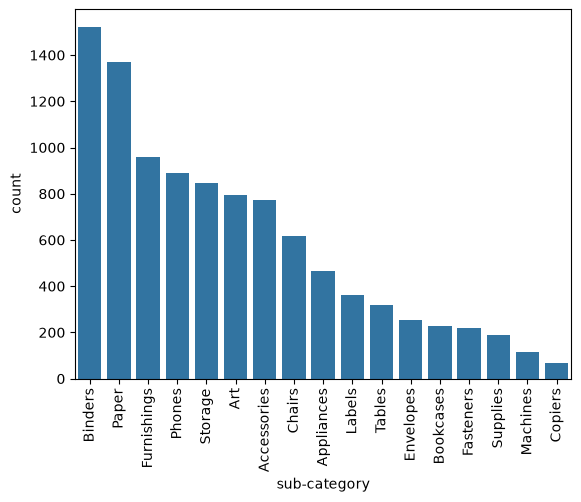

In [158]:
sns.countplot(data=df, x='sub-category', order=labels)
plt.xticks(rotation=90)
plt.show()

**Observations:**
- *The Sub category have 17 types*